In [6]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "elo-meriem"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "elo-meriem" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

#today_dir = "Comparative Experiments"
today_dir = "Assignments"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/elo-meriem/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW4/STAT-7220-Applied-Experimental-Design/Assignments/STAT-7220-Applied-Experimental-Design/Assignments/STAT-7220-Applied-Experimental-Design
⚠️ WARNING: You are working in the instructor's repo, not your fork!
💡 Please fork the repo to your own account and update `github_username` above.
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW4/STAT-7220-Applied-Experimental-Design/Assignments/STAT-7220-Applied-Experimental-Design/Assignments/STAT-7220-Applied-Experimental-Design/Assignments


# STAT 7220 - Homework 4
## Mixed Effects Experiments
## Dr. Austin Brown
## Due Date: April 24, 2026

## Instructions:

The International Paralympic Committee is evaluating two new carbon-fiber blade designs: Model A (Aerostep) and Model B (Bionic-Flex). The goal is to determine if either new design yields meaningfully different 100-meter sprint times among T64 sprinters. Note, a T64 sprinter is an athlete with an absence of one leg below the knee.

Because sprint performance is highly dependent on an individual athlete’s biomechanics, muscle composition, and training level, the research team has recruited 5 professional T64 sprinters to participate in a study. Each athlete will perform three timed trials with both of the blade types in a randomized order. In this experiment, we want to control for the variability of individual athletes, but we are most interested in comparing the mean differences between the two blade designs. The results of this experiment are contained in the `Paralympic_Blade_Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

The objective of this experiment is to determine whether there is a statistically l difference in 100-meter sprint performance between two carbon-fiber prosthetic blade designs Model A (Aerostep) and Model B (Bionic-Flex) among T64 sprinters

2.  Specify the outcome variable and how it is measured.

100-meter sprint times among T64 sprinters

3.  Specify the independent variables, including which is fixed and which is random. What lurking variables may be present?

independent variables:

- blade design: Model A (Aerostep) and Model B (Bionic-Flex) :Fixed
- Sprinters: 5 professional T64 sprinter : Random
- Trial number: 3trials per blade per sprinter : Random

Lurking variables:

- the order of blade used
- fatigue: performance might decline across trials
- Environmental conditions: temperature/ wind...
- physical condition:sleep/ recovery

4.  Explain the difference between a random effect and a fixed effect. Why should we account for random effects in our designs?

Fixed factor :is a factor whose specific levels are the only ones of interest in the study.in our example :Model A vs Model B are fixed factors because the goal is to compare these two blade designs

Random effects: levels are considered a random sample from a larger population, in our example, the 5 sprinters are random effects because they represent a sample of the broader population of T64 sprinters

accounting for random effect would help us correctly handle the natural variability among sprinters (strength differences, technique and biomechanic) ensuring that the comparison between the two blade designs is fair and generalizable

5.  State the sets of null and alternative hypotheses for this experiment.


$$ \begin{align*} &H_{01}: \alpha_{\text{Aerostep}} = \alpha_{\text{Bionic-Flex}}\\
                  &H_{11}: \alpha_{\text{Aerostep}} ≠ \alpha_{\text{Bionic-Flex}}\\ \\
                  &H_{02}: \sigma^2_b = 0 \\
                  &H_{12}: \sigma^2_b > 0
   \end{align*}
   $$


6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

  Athlete_ID   Blade_Type  Trial  Sprint_Time
0  Athlete_1     Aerostep      1        11.63
1  Athlete_1     Aerostep      2        11.57
2  Athlete_1     Aerostep      3        11.39
3  Athlete_1  Bionic-Flex      1        11.74
4  Athlete_1  Bionic-Flex      2        11.68
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Athlete_ID   30 non-null     object 
 1   Blade_Type   30 non-null     object 
 2   Trial        30 non-null     int64  
 3   Sprint_Time  30 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ KB
None
  Athlete_ID   Blade_Type       mean       std
0  Athlete_1     Aerostep  11.530000  0.124900
1  Athlete_1  Bionic-Flex  11.703333  0.032146
2  Athlete_2     Aerostep  10.960000  0.034641
3  Athlete_2  Bionic-Flex  11.133333  0.051316
4  Athlete_3     Aerostep  11.273333  0.032146
5  Athlete_3  Bionic-

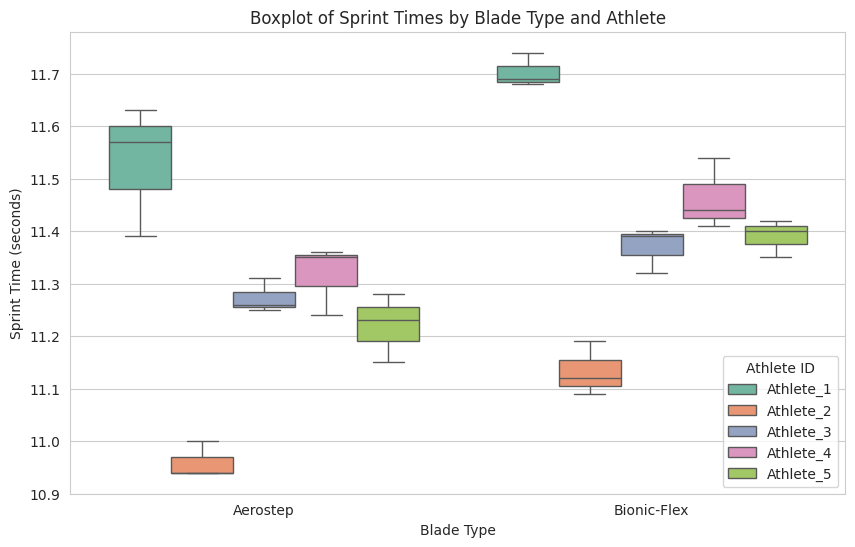

In [13]:
## Question 6 Code ##
import seaborn as sns
import matplotlib.pyplot as plt

#%pip install openpyxl
## Import pandas ##

import pandas as pd

## Import .xlsx File ##
Blade_Experiment_data = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/HW4/STAT Paralympic_Blade_Experiment.xlsx")

## Evaluate Data Integrity ##

print(Blade_Experiment_data.head())
print(Blade_Experiment_data.info())

#Calculate Summary Statistics by Athlete and Blade Type
blade_stats = Blade_Experiment_data.groupby(['Athlete_ID', 'Blade_Type'])['Sprint_Time'].agg(['mean', 'std']).reset_index()
print(blade_stats)

## Visualize Data using Boxplots ##

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='Blade_Type',
    y='Sprint_Time',
    hue='Athlete_ID',
    data=Blade_Experiment_data,
    palette='Set2'
)

plt.title('Boxplot of Sprint Times by Blade Type and Athlete')
plt.xlabel('Blade Type')
plt.ylabel('Sprint Time (seconds)')
plt.legend(title='Athlete ID')
plt.show()


-Looking at these results, it appears that the Aerostep blade tends to produce lower mean sprint times compared to the Bionic-Flex blade.
    - This gives us some evidence in favor of $H_{11}$.

- Additionally,it appears to be variability in sprint times across athletes with Athlete 1 consistently showing higher sprint times across both blade type

    - This gives us some evidence in favor of $H_{12}$.


7. Fit the mixed effects model. Using the model residuals, check the assumption of normality using both a testing method and a visual method. Do we have support for the assumption of normality from the data? Why or why not?

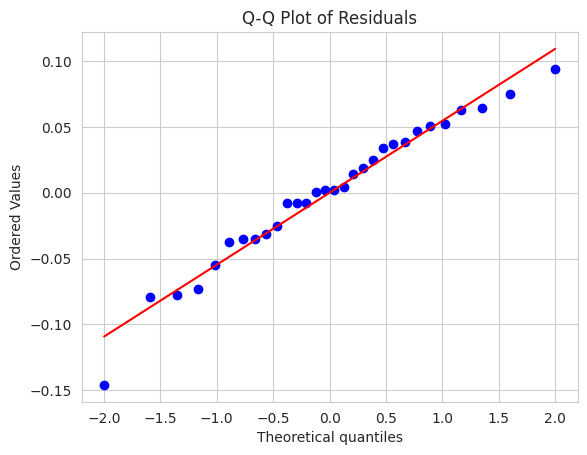

Shapiro-Wilk Test Statistic: 0.9713
Shapiro-Wilk Test P-Value: 0.5746
The residuals are normally distributed (fail to reject H0).


In [15]:
## Question 7 Code ##
from statsmodels.formula.api import mixedlm, ols
import statsmodels.api as sm
from scipy import stats


## Fit the Full Mixed Effects Model ##

mixed_mod = mixedlm("Sprint_Time~Blade_Type",data=Blade_Experiment_data, groups=Blade_Experiment_data["Athlete_ID"])
mixed_result = mixed_mod.fit(reml=False,method='nm')


# Assessing Normality ##

## Extract Model Residuals ##
residuals = mixed_result.resid

## Generate QQ plot using seaborn ##
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()


## Perform Shapiro-Wilk Test ##
## Perform Shapiro-Wilk Test on Model Residuals ##
shapiro_test = stats.shapiro(mixed_result.resid)

## Get Test Statistic ##
shapiro_stat = shapiro_test.statistic

## Get P-Value ##
shapiro_pvalue = shapiro_test.pvalue

print(f"Shapiro-Wilk Test Statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {shapiro_pvalue:.4f}")

if shapiro_pvalue < 0.05:
    print("The residuals are not normally distributed (reject H0).")
else:
    print("The residuals are normally distributed (fail to reject H0).")



From the results of our visual and testing method of evaluating the normality assumption, we can see that the data support the assumption of normality given that:

The points in the QQ-plot all generally fall along the line bisecting the plot with little deviation. additionally, The Shapiro-Wilk test indicates that the residuals are not significantly different from a normal distribution (p = 0.5746)

8. **Using the visual method described in the lecture notes**, check the assumption of constant variance. Do we have support for the assumption of constant variance? Why or why not?

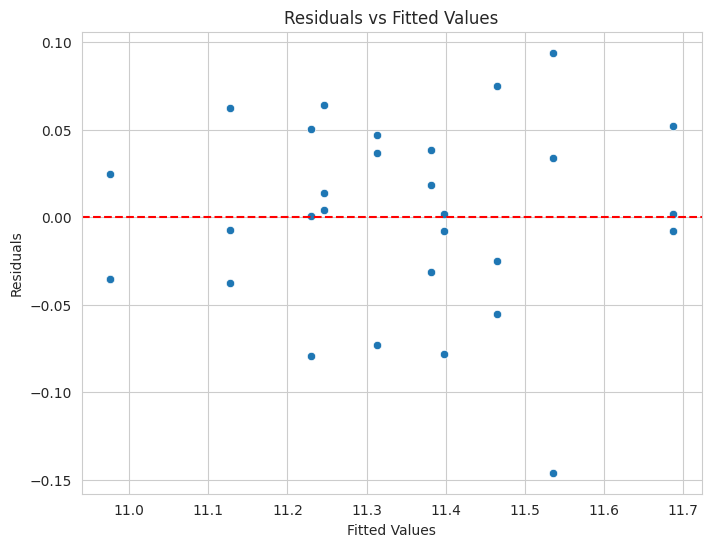

F-statistic: 1.758774701035814
F p-value: 0.19549437688748963
No heteroscedasticity detected (fail to reject H0).


In [22]:
## Question 8 Code ##

## Constant Variance Check ##

import matplotlib.pyplot as plt
import seaborn as sns

## Residuals ##
residuals = mixed_result.resid

## Fitted values ##
fitted_values = mixed_result.fittedvalues

## Plot ##
plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=residuals)

plt.axhline(0, color='red', linestyle='--')

plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()


#bp test
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(
    mixed_result.resid,
    mixed_result.model.exog
)

f_statistic = bp_test[2]
f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")

if f_p_value < 0.05:
    print("Heteroscedasticity detected (reject H0).")
else:
    print("No heteroscedasticity detected (fail to reject H0).")

In the residuals vs fitted values plot, the points are randomly scattered around zero with no clear pattern or funnel shape. This indicates that the variability of the residuals remains relatively constant across all fitted values.

Additionally, the Breusch–Pagan test produced a p-value greater than 0.05, indicating that we fail to reject the null hypothesis of constant variance. Therefore, there is no evidence of heteroscedasticity in the model.

9. Report and interpret the result of the random effect. Which of the two hypotheses for the random effect are more strongly supported by the data?




In [25]:
## Question 9 Code ##
from scipy.stats import chi2

## Fit the Full Mixed Effects Model ##

mixed_mod = mixedlm("Sprint_Time~Blade_Type",data=Blade_Experiment_data, groups=Blade_Experiment_data["Athlete_ID"])
mixed_result = mixed_mod.fit(reml=False,method='nm')

## Fit the Reduced Model (Note this is keeping the fixed effect) ##

reduced_mod = ols('Sprint_Time ~ Blade_Type', data=Blade_Experiment_data).fit()

## Perform Likelihood Ratio Test ##

ll_full = mixed_result.llf
ll_reduced = reduced_mod.llf

LR_stat = 2 * (ll_full - ll_reduced)
p_value = 0.5 * (1 - chi2.cdf(LR_stat, df=1))
print(f"Likelihood Ratio Test Statistic: {LR_stat}, p-value: {p_value}")



Likelihood Ratio Test Statistic: 51.1890964501146, p-value: 4.1944225870338414e-13


random effect (Sprinter):

- The LR test statistic is 51.19 with an associated p-value much less than 0.05.
- This suggests that we have strong evidence to suggest that $\sigma^2_b > 0$.

10. Report and interpret the result of the fixed effect. Which of the two hypotheses for the fixed effect are more strongly supported by the data?

In [26]:
## Question 10 Code ##

## Perform test for fixed effect ##

print(mixed_result.summary())

                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     Sprint_Time
No. Observations:     30          Method:                 ML         
No. Groups:           5           Scale:                  0.0033     
Min. group size:      6           Log-Likelihood:         32.8616    
Max. group size:      6           Converged:              Yes        
Mean group size:      6.0                                            
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                 11.260    0.082 136.819 0.000 11.099 11.421
Blade_Type[T.Bionic-Flex]  0.152    0.021   7.241 0.000  0.111  0.193
Group Var                  0.033    0.401                            



- Aerostep is treated as the reference blade type, so it does not appear explicitly in the coefficient table.

- The coefficient for Bionic-Flex (0.152) represents the estimated difference in mean sprint time compared to Aerostep.

- Since this coefficient is positive, it indicates that Bionic-Flex results in slower sprint times on average compared to Aerostep.

- The associated p-value is less than 0.05, indicating that this difference is statistically significant.

- Therefore, the data provide stronger support for the alternative hypothesis $H_{11}$, suggesting that at least one blade type (Bionic-Flex) has a significantly different mean sprint performance compared to the reference (Aerostep).

11. Finally, provide a brief contextual conclusion for this experiment. Discuss experiment limitations and future directions.